<center><h1>QBUS2820 - Predictive Analytics</h1></center>

# Tutorial 2 - Linear Regression


## Regression

A regression model is a supervised learning model which predicts target variable that is continuous. For example house price and temperature are continuous variables. On the other hand a categorical variable like brand of car is not continuous.

Generally there are two types of regression

**Simple Linear Regression (SLR)**
$$ f(\mathbf{x}) = \beta_0 + \beta_1 x $$

**Multiple Linear Regression (MLR)**
$$ f(\mathbf{x}) = \beta_0 + \beta_1 x_1 + \dots + \beta_p x_p$$

**Simple** regression means that we only use one feature, whereas **Multiple** regression means that we use multiple features in the model to explain the target variable.

A regression model can be compactly described by the parameters $\beta$. They represent the effect or weight of each feature on the value of the target. Training a regression model is the process of finding the best parameters to minimise the error between observed training target and predicted target values.


## Predict House Price Example

Let's look at an example using house price data collected in Baton Rouge, Louisiana, US, from mid-2005.

The following variables are included in the file br.xls:

- Price: The price the house sold for;
- Square Feet: The size of the house in square feet;
- Beds: The number of bedrooms in the house;
- Baths: The number of bathrooms in the house;
- Age: The age of the house in years;
- Pool: Does the house have a pool (yes/no)?
- Style: What is the architectural style of the house?
- Fireplace: Does the house have a fireplace (yes/no)?
- Waterfront: Is the house on the waterfront (yes/no)?
- Days on Market: How many days the house spent on the market before it was ultimately sold?

### Framing the Problem

Given the Baton Rouge data, we can do many regressions depending on which variable we select as the target or features. However there are two guiding questions you can ask yourself:

- Which variable can you estimate from the others? (what is the dependnacy order of variables)?
- What is your goal?

In this example our goal is to predict the house price. House price is the most obvious dependant variable. All others have only weak dependency on each other. For example, we expect that a bigger house is more expensive. But a more expensive house is not always bigger (due to factors such as location).

**Target variable**: Price

**Features/predictors**: All other variables

In [1]:
import pandas as pd

br = pd.read_excel("BatonRouge.xls")

br.head()

,Price,SQFT,Bedrooms,Baths,Age,Pool,Style,Fireplace,Waterfront,DOM
0,66500,741,1,1,18,1,1,1,0,6
1,66000,741,1,1,18,1,1,0,0,23
2,68500,790,1,1,18,0,1,1,0,8
3,102000,2783,2,2,18,0,1,1,0,50
4,54000,1165,2,1,35,0,1,0,0,190


### Categorical variables

Notice that some variables are categorical. This presents a potential complication: creating dummy variables which are also known as boolean indicator variables.

For each category, a new binary variable is created. If the data point falls into a category, the corresponding dummy variable is set to 1; otherwise, it is set to 0. In a linear regression setting, if there are  $k$  categories,  $k-1$  dummy variables are typically used to avoid multicollinearity.

Let’s illustrate this with a simple example dataset containing a single categorical variable.

In [2]:
s = pd.Series(list('abca'))
s

0    a
1    b
2    c
3    a
dtype: object

We can get the dummy variables for this dataset by using the ``pandas`` function``get_dummies()``. Notice that we have transformed a single variable into three new variables, one for each category.

In [3]:
pd.get_dummies(s)

,a,b,c
0,True,False,False
1,False,True,False
2,False,False,True
3,True,False,False


However, we should drop one of the categories to avoid multicolinearity. The ``get_dummies()`` function has a parameter called ``drop_first`` to do this for you.

In [4]:
s = pd.get_dummies(s, drop_first=True)
s

,b,c
0,False,False
1,True,False
2,False,True
3,False,False


## Simple Linear Regression

First we will build a simple linear regression model.

We know the dependant variable is price, but which independant variable will best predict the price? To determine this you can use two heuristics:

1. Scatter Plotting: Plot each independent variable against the dependent variable (price) to visually inspect potential relationships.
2. Linear Correlation: Calculate the correlation coefficient between each independent variable and the dependent variable. A higher absolute value indicates a stronger linear relationship.
    
However, be cautious with correlation scores, as they only capture linear relationships and may miss strong non-linear associations.

In [5]:
correlations = br.corr()
#correlations.iloc[:, 0]
correlations

,Price,SQFT,Bedrooms,Baths,Age,Pool,Style,Fireplace,Waterfront,DOM
Price,1.000000,0.760689,0.455189,0.645341,-0.208609,0.202269,0.149208,0.310626,0.309940,0.078929
SQFT,0.760689,1.000000,0.684591,0.716111,-0.138031,0.256155,0.126682,0.374238,0.214929,0.104335
Bedrooms,0.455189,0.684591,1.000000,0.578808,-0.168075,0.137703,0.037503,0.210015,0.085691,0.089487
Baths,0.645341,0.716111,0.578808,1.000000,-0.293107,0.202991,0.108446,0.364095,0.222732,0.074509
Age,-0.208609,-0.138031,-0.168075,-0.293107,1.000000,0.009081,-0.016037,-0.209634,-0.165418,-0.064640
Pool,0.202269,0.256155,0.137703,0.202991,0.009081,1.000000,0.026452,0.107466,0.089701,-0.027832
Style,0.149208,0.126682,0.037503,0.108446,-0.016037,0.026452,1.000000,0.170782,0.151026,0.017137
Fireplace,0.310626,0.374238,0.210015,0.364095,-0.209634,0.107466,0.170782,1.000000,0.123235,0.062615
Waterfront,0.309940,0.214929,0.085691,0.222732,-0.165418,0.089701,0.151026,0.123235,1.000000,0.119755
DOM,0.078929,0.104335,0.089487,0.074509,-0.064640,-0.027832,0.017137,0.062615,0.119755,1.000000


It looks like the house area (sqft) has the largest linear sample correlation with price. Let's confirm this with a quick scatter plot.

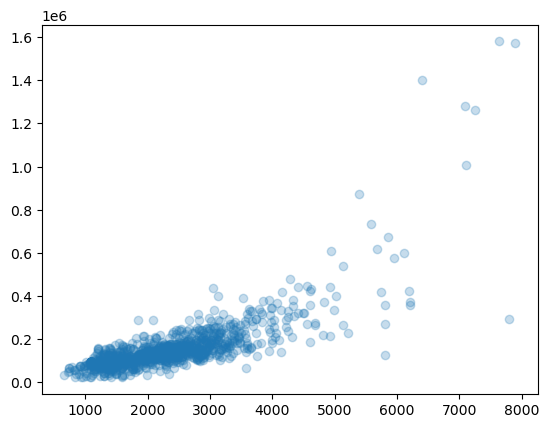

In [7]:
import matplotlib.pyplot as plt

y = br['Price']
x = br['SQFT']

fig = plt.figure()
plt.scatter(x, y, alpha=0.25)
plt.show()

Add the intercept term $\beta_0$ to the dataframe

In [8]:
import statsmodels.api as sm

x_with_intercept = sm.add_constant(x, prepend=True)

x_with_intercept.head()

,const,SQFT
0,1.0,741
1,1.0,741
2,1.0,790
3,1.0,2783
4,1.0,1165


Fit the model and display the summary of the model. The summary will display the coefficient values ($\beta$) and statistics such as the R-squared and p-value etc.

In [9]:
model = sm.OLS(y, x_with_intercept)

results = model.fit()

print(results.summary())

                            OLS Regression Results                            
Dep. Variable:                  Price   R-squared:                       0.579
Model:                            OLS   Adj. R-squared:                  0.578
Method:                 Least Squares   F-statistic:                     1480.
Date:                Fri, 26 Jul 2024   Prob (F-statistic):          1.54e-204
Time:                        01:45:49   Log-Likelihood:                -13722.
No. Observations:                1080   AIC:                         2.745e+04
Df Residuals:                    1078   BIC:                         2.746e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const      -6.086e+04   6110.187     -9.961      0.0

### Estimate SLR coefficients with $\hat{\beta} = (\mathbf{X}^T\mathbf{X})^{-1}\mathbf{X}^T\mathbf{Y}$

In [10]:
y = br['Price']
x = br['SQFT']

In [11]:
import numpy as np

# Add a column of ones for beta_0
X = np.column_stack((np.ones(len(x)), x))
# Convert X to a matrix
X = np.asmatrix(X)

# Estimate linear regression coefficients 
lin_betas = np.linalg.inv(X.T*X) * X.T * y.values.reshape(len(x),1)

In [12]:
X[1,:]


matrix([[  1., 741.]])

Note the size of matrix ``X.T*X``.

In [13]:
print(X.T*X)

[[1.08000000e+03 2.51201300e+06]
 [2.51201300e+06 6.93933262e+09]]


Print the inverse of ``X.T*X``.

In [14]:
np.linalg.inv(X.T*X)

matrix([[ 5.85958699e-03, -2.12114904e-06],
        [-2.12114904e-06,  9.11954261e-10]])

Print the estimated parameters.

In [15]:
# beta_0
lin_intercept = lin_betas[0,0]
print("intercept (beta_0): {0:.2f}".format(lin_intercept))

# beta_1
lin_beta = lin_betas[1,0]
print("beta_1: {0:.2f}".format(lin_beta))

intercept (beta_0): -60861.46
beta_1: 92.75


Compare the above resutls with the ones from sm.OLS.

### Defining model using a formula

An alternative is to use the ``statsmodels`` ``formula`` interface to define your model. Statsmodels will pass a string as a formula and select the named columns from the DataFrame.

In [16]:
import statsmodels.formula.api as smf

formula = "Price ~ SQFT"

model_formula = smf.ols(formula = formula, data = br)

results_formula = model_formula.fit()

## Plotting the regression model

To visualize the regression model, you can generate predicted values for the dependent variable ($y$) using a range of evenly spaced values for the independent variable ($x$). Here’s how to do it:

1. Generate Evenly Spaced Values for $x$: Use ``numpy`` to create a range of $x$ values across the domain of the independent variable.
2. Calculate $y$ Values: Use the model parameters (coefficients $\beta$) to compute the corresponding $y$ values.

In [17]:
import numpy as np
# by doing the below to avoid extrapolation
min_x = np.min(x)
max_x = np.max(x)

x_points = np.linspace(min_x, max_x, 100)

y_model = results.params.iloc[0] + results.params.iloc[1] * x_points

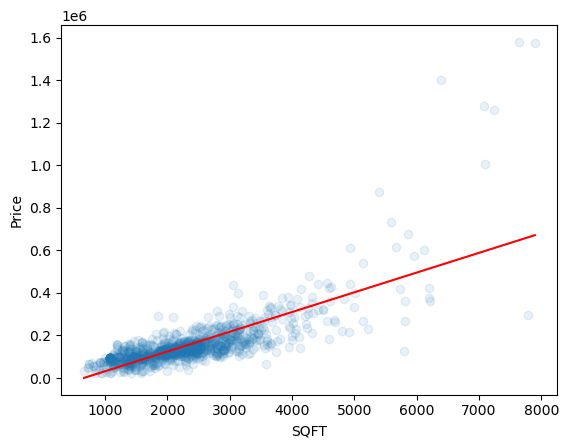

In [18]:
fig = plt.figure()

plt.scatter(x, y, alpha = 0.1)

plt.plot(x_points, y_model, color = "red")

plt.xlabel("SQFT")
plt.ylabel("Price")

plt.show()

If you have a multiple regression model, it is probably easier to use the ``statsmodels`` ``predict()`` function

In [19]:
x_model = np.array([np.ones(100), x_points])
x_model = x_model.transpose()

y_model = results.predict(x_model)

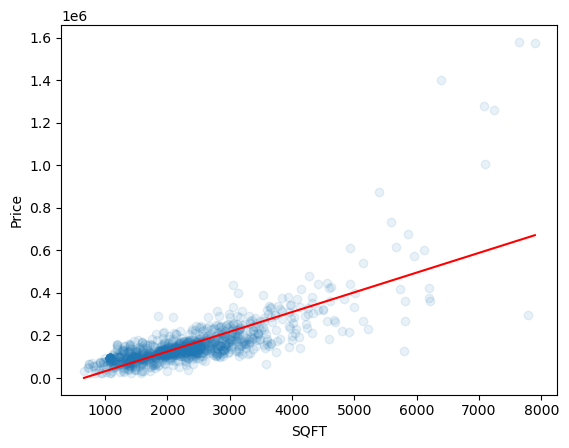

In [20]:
fig = plt.figure()

plt.scatter(x, y, alpha = 0.1)

plt.plot(x_points, y_model, color = "red")

plt.xlabel("SQFT")
plt.ylabel("Price")

plt.show()

## Evaluating the Model

How can we quantify the ability of our model to reflect the data?

## Improving the Model

Let's try to improve our model by including all the available features.

In [21]:
import seaborn as sns  # This helps us plot and visualize the data in a more fancy way

In [22]:
x = br.iloc[:, 1:]

x_with_intercept = sm.add_constant(x, prepend=True)

In [23]:
x_with_intercept.head()

,const,SQFT,Bedrooms,Baths,Age,Pool,Style,Fireplace,Waterfront,DOM
0,1.0,741,1,1,18,1,1,1,0,6
1,1.0,741,1,1,18,1,1,0,0,23
2,1.0,790,1,1,18,0,1,1,0,8
3,1.0,2783,2,2,18,0,1,1,0,50
4,1.0,1165,2,1,35,0,1,0,0,190


Inspect and visualize the data to investigate which variables do you think would be helpful to explain the hourse price. Also, the plots can be used to detect potential multicolinearity problem.

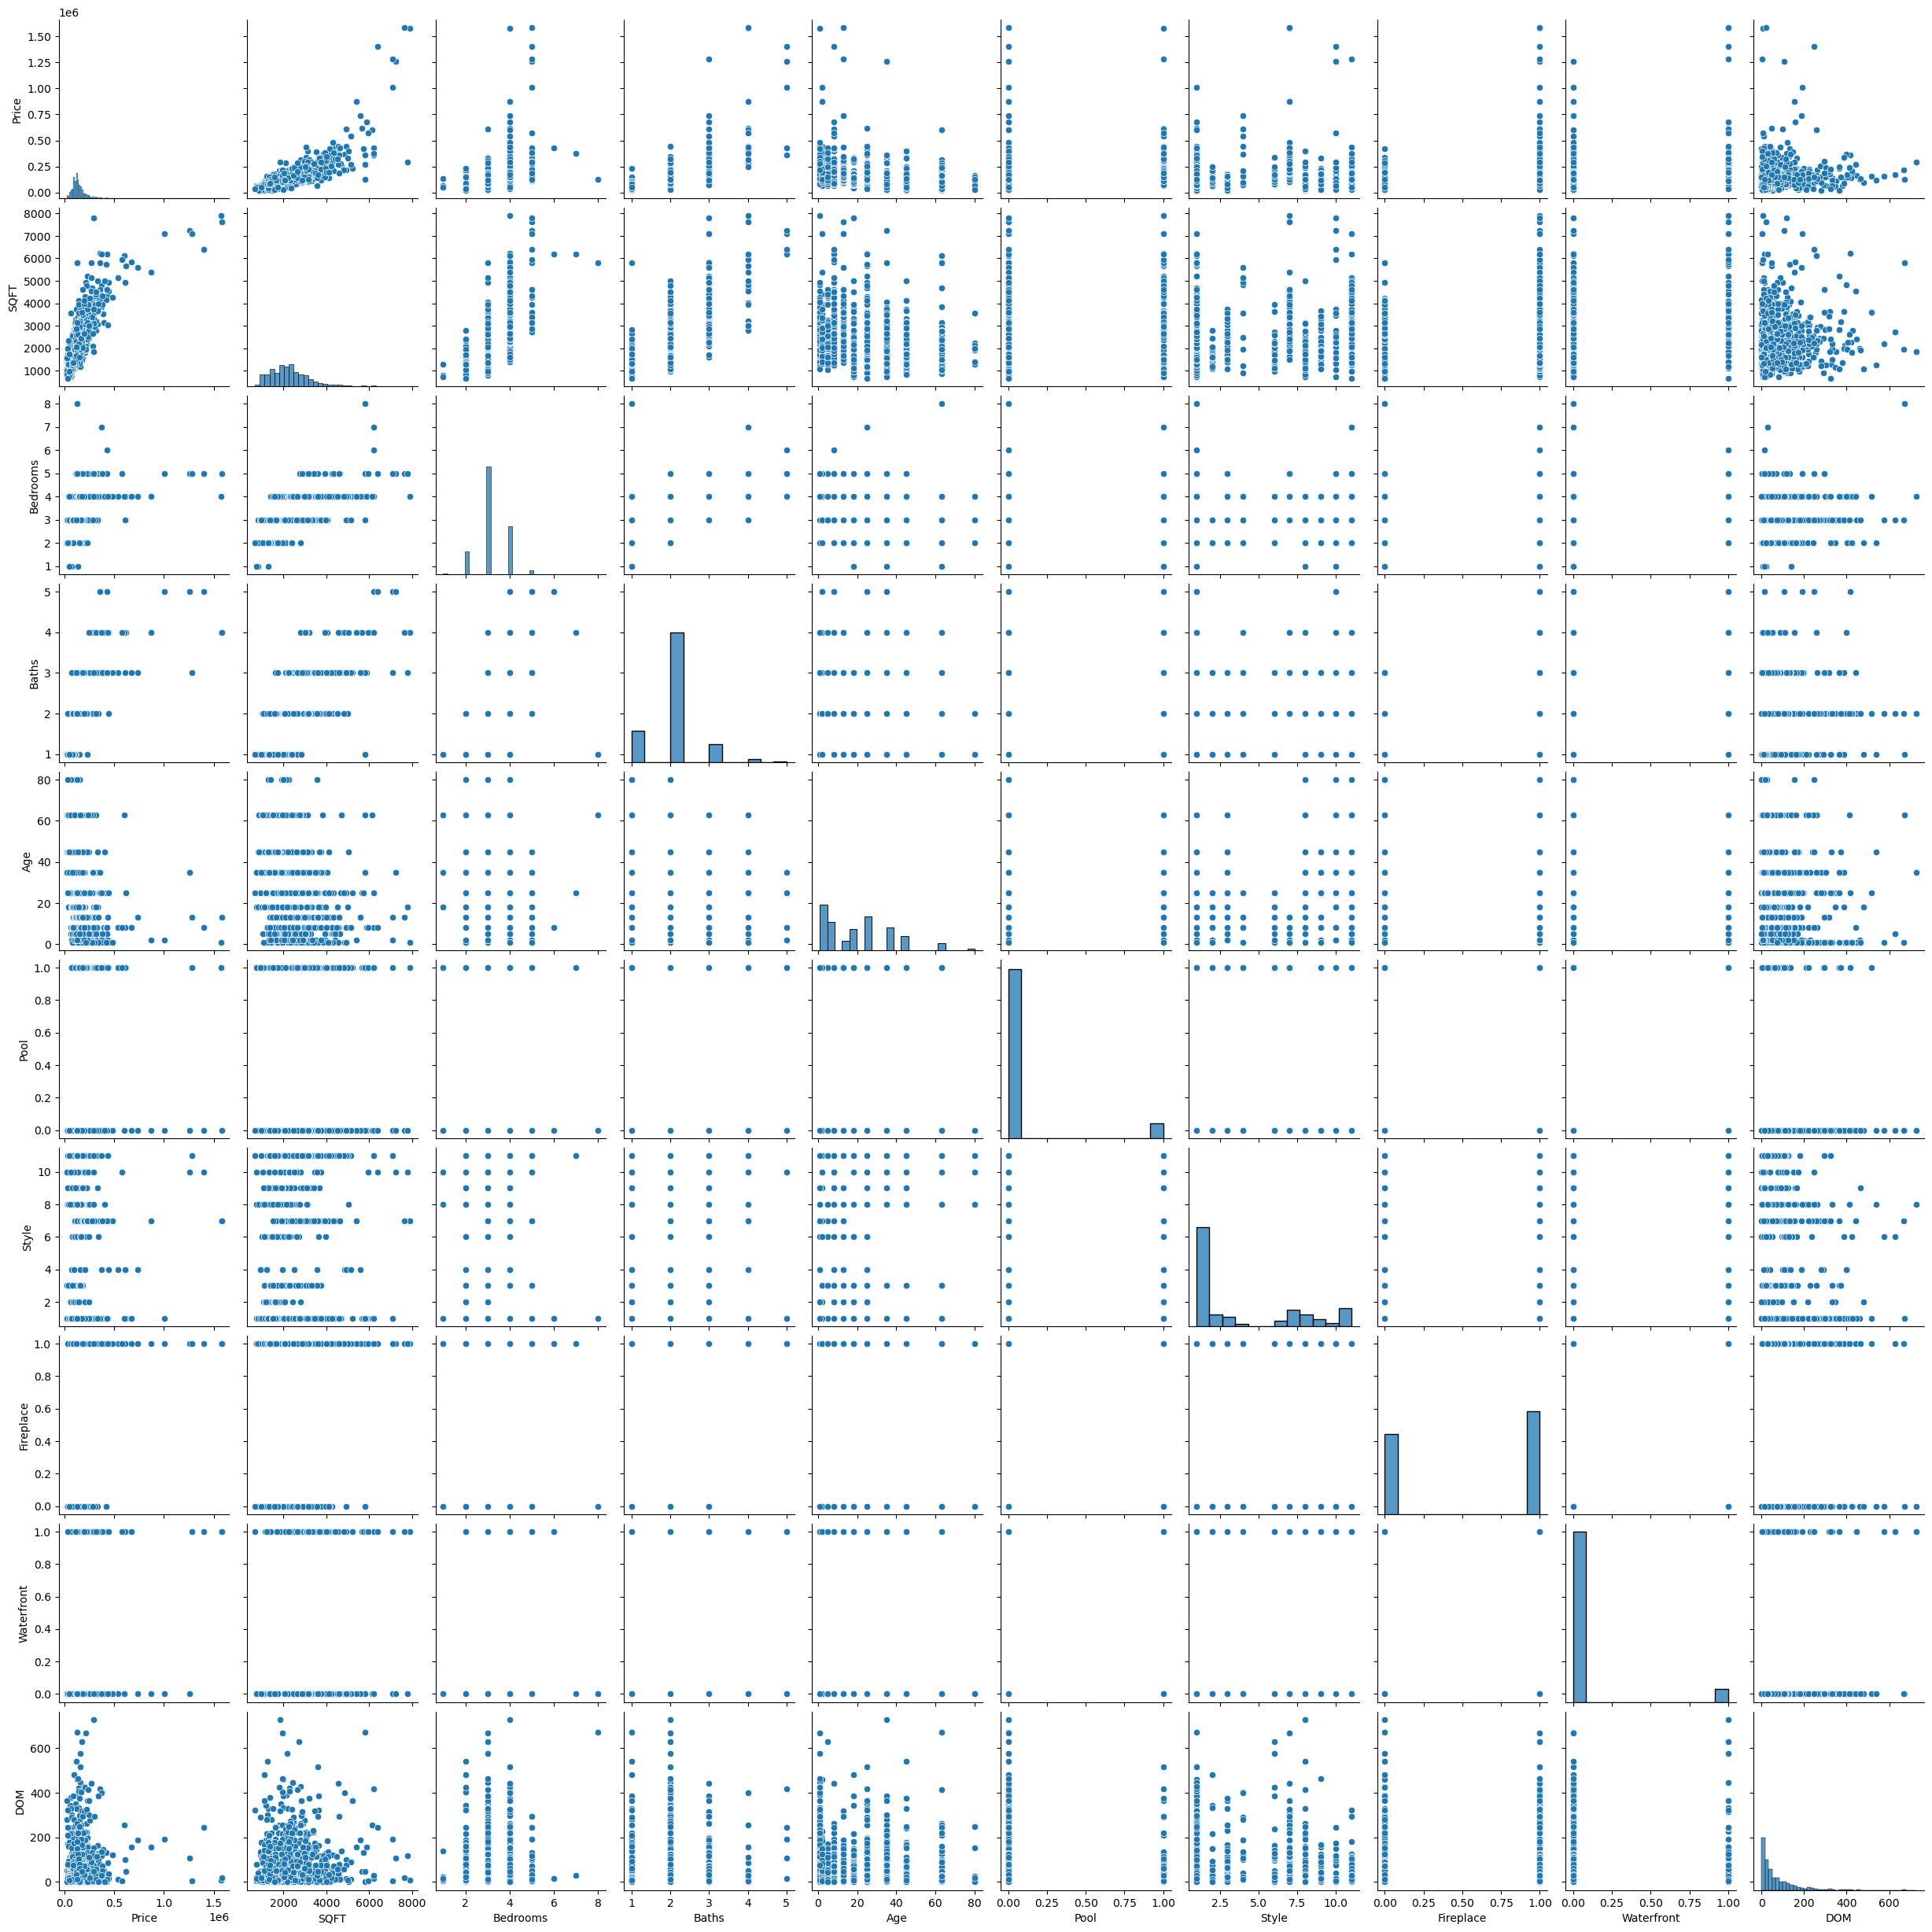

In [24]:
# Plot a pairwise plot to quickly inspect the relationship between each pair of variables
# This only compares the numerical data
sns.pairplot(br)
plt.show()

In [25]:
model_multivariate = sm.OLS(y, x_with_intercept)

results_multivariate = model_multivariate.fit()

print(results_multivariate.summary())

                            OLS Regression Results                            
Dep. Variable:                  Price   R-squared:                       0.633
Model:                            OLS   Adj. R-squared:                  0.630
Method:                 Least Squares   F-statistic:                     205.3
Date:                Fri, 26 Jul 2024   Prob (F-statistic):          5.20e-226
Time:                        01:46:16   Log-Likelihood:                -13647.
No. Observations:                1080   AIC:                         2.731e+04
Df Residuals:                    1070   BIC:                         2.736e+04
Df Model:                           9                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const      -3.117e+04   1.29e+04     -2.421      0.0

#### Do we have a better model?

### Estimate MLR coefficients with $\hat{\beta} = (\mathbf{X}^T\mathbf{X})^{-1}\mathbf{X}^T\mathbf{Y}$

In [26]:
x = br.iloc[:, 1:]
X = np.column_stack((np.ones(len(x)), x))

In [27]:
X[1,:]

array([  1., 741.,   1.,   1.,  18.,   1.,   1.,   0.,   0.,  23.])

In [28]:
# Add a column of ones for beta_0
X = np.column_stack((np.ones(len(x)), x))
# Convert X to a matrix
X = np.asmatrix(X)

Let's also check the rank of X.T*X

In [29]:
print(np.linalg.matrix_rank(X.T*X))

10


The determinant of X.T*X

In [30]:
print(np.linalg.det(X.T*X))

2.560636905516424e+39


The matrix X.T*X has full rank and non-zero determinant, so it is invertible

In [31]:
# Estimate linear regression coefficients 
lin_betas = np.linalg.inv(X.T*X) * X.T * y.values.reshape(len(x),1)

In [32]:
# print all the estimated parameters
print(lin_betas)

[[-3.11685335e+04]
 [ 8.48963685e+01]
 [-2.59873253e+04]
 [ 3.89465439e+04]
 [-4.71870110e+02]
 [-1.68199949e+03]
 [ 1.02807257e+03]
 [-5.34854906e+03]
 [ 5.64310846e+04]
 [-1.62243883e+01]]


## Predicting the house price

Prediction means to predict a value given the model parameters and some new data. For example, we might want to predict the sale price of a house that is about to go on the market.

### Non-Formula

When using the non-formula method you can simply pass in an array/list of values. Don't forget to include the intercept if you used it!

In [33]:
new_house = [1, 1500]
# we use the trained SLR model
results.predict(new_house)

array([78259.59937286])

### Formula

If you use a formula to build the model you need to use labelled values. The easiest way to do it for a simple case is with a list of dictionaries.

In [34]:
new_house_dict = {'SQFT': 1500}

results_formula.predict( new_house_dict )

0    78259.599373
dtype: float64

You can also use a pandas DataFrame.

In [35]:
new_house_df = pd.DataFrame([{'SQFT': 1500}])

results_formula.predict( new_house_df )

0    78259.599373
dtype: float64